# Area of Interest | Network | Isochrones
### This notebook contains an example of using accessX to prepare the area of analysis, analyse the street network, and estimate walking isochrones for Amsterdam, Athens, and Milan.

In [24]:
import accessx as acx
import osmnx as ox
import os
import matplotlib.pyplot as plt

### Load Area of Interest

In [ ]:
# (1) Use OSMnx to geocode a city's boundaries and get its geometry as a GeoDataFrame
#This step can be done reading the actual city boundary from a file, 
# but this is a quick way to get it for demonstration purposes.

epsg_ams = 28992
epsg_ath = 2100
epsg_mil = 32632

data_path = "../data/case_studies"

gdf_ams = ox.geocode_to_gdf("Amsterdam, Netherlands")
gdf_ath = ox.geocode_to_gdf("Municipality of Athens, Greece")
gdf_mil = ox.geocode_to_gdf("Milan, Italy")

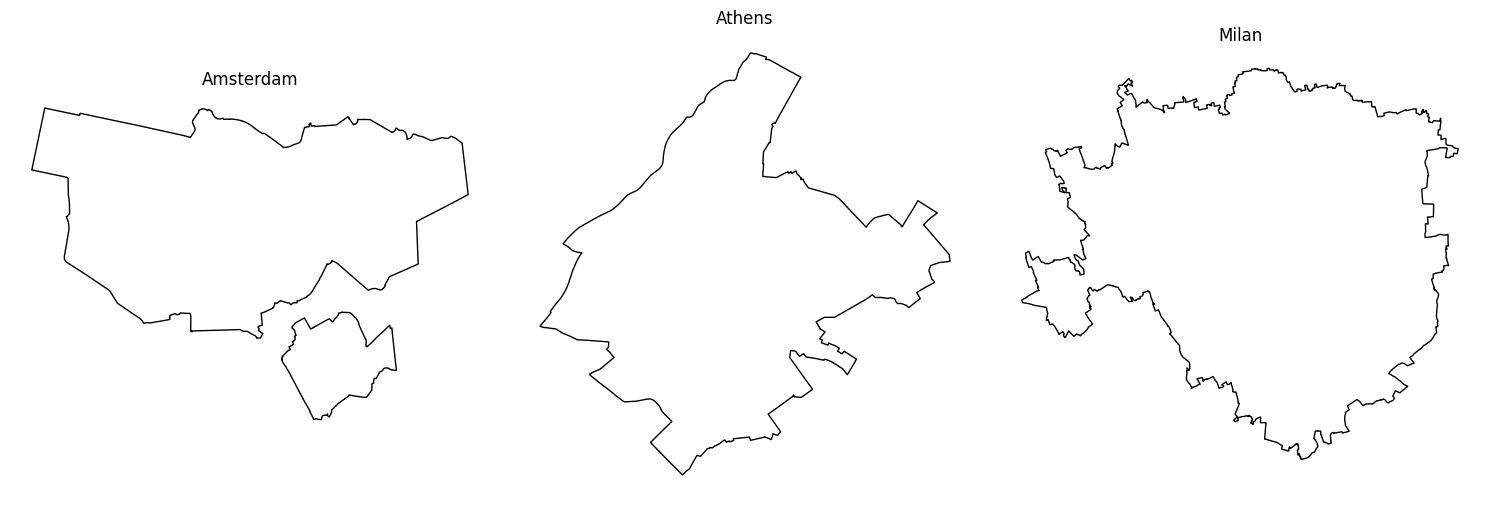

In [ ]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gdfs = [gdf_ams, gdf_ath, gdf_mil]
titles = ["Amsterdam", "Athens", "Milan"]

for ax, gdf, title in zip(axes, gdfs, titles):
    gdf.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Make Hex Grid

In [3]:
ams_hex = acx.make_hex_grid(aoi=gdf_ams, resolution=9)    
ath_hex = acx.make_hex_grid(aoi=gdf_ath, resolution=9)    
mil_hex = acx.make_hex_grid(aoi=gdf_mil , resolution=9)    

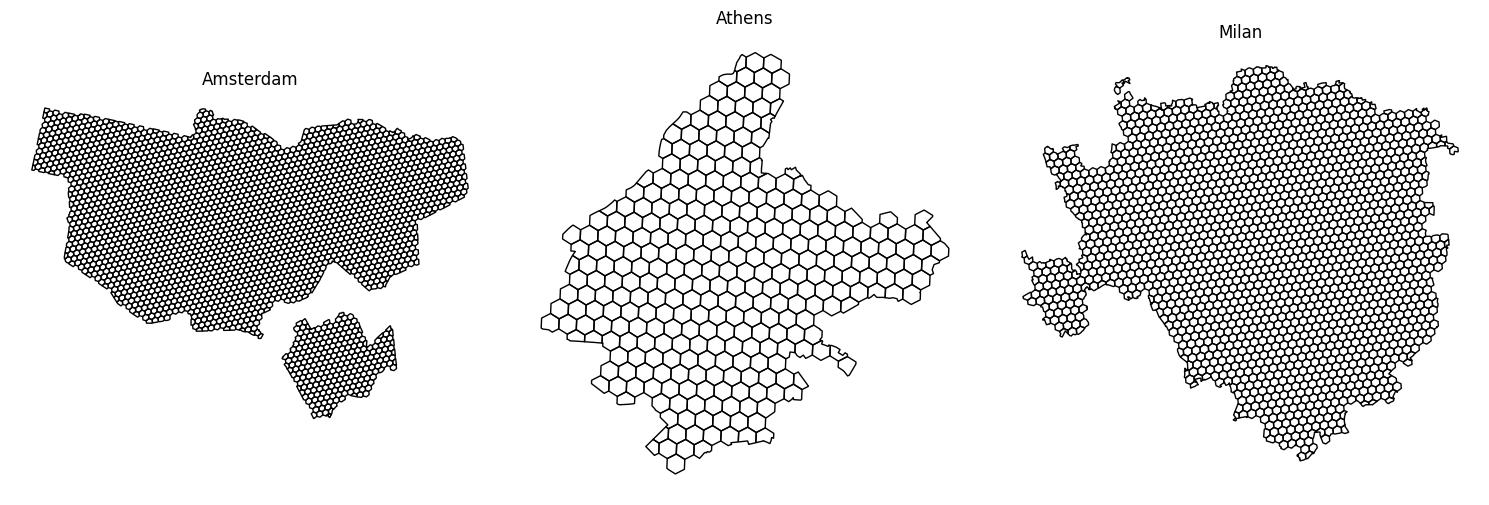

In [8]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gdfs = [ams_hex, ath_hex, mil_hex]
titles = ["Amsterdam", "Athens", "Milan"]

for ax, gdf, title in zip(axes, gdfs, titles):
    gdf.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Download Street Network

In [ ]:
cities = [
    {"name": "amsterdam", "aoi": gdf_ams, "epsg": epsg_ams},
    {"name": "athens", "aoi": gdf_ath, "epsg": epsg_ath},
    {"name": "milan", "aoi": gdf_mil, "epsg": epsg_mil},
]

buffer = 1000
graphs = {}

for city in cities:
    G_proj = acx.build_network(
        AOI=city["aoi"],
        city_epsg=city["epsg"],
        buffer_m=buffer,
        network_type="walk",
        simplify=False,
        retain_all=True,
    )

    acx.save_graph(
        G_proj,
        out_dir=data_path + "/street_network/",
        base_name=f"original_graph_{city['name']}",
        save_nodes=True,
        save_edges=True,
    )
    graphs[city["name"]] = G_proj


### Add travel cost to the network
Add constant speed

In [19]:
# Read the graph 

cities = [
    {"name": "amsterdam", "epsg": epsg_ams},
    {"name": "athens", "epsg": epsg_ath},
    {"name": "milan", "epsg": epsg_mil},
]

graphs_with_speeds = {}

for city in cities:
    G_proj = acx.load_graph(
        nodes_path=data_path + f"/street_network/original_graph_{city['name']}_nodes_OSM.geojson",
        edges_path=data_path + f"/street_network/original_graph_{city['name']}_edges_OSM.geojson",
        crs=city["epsg"]
    )

    G_proj = acx.add_time_cost_constant_speed(
        G_proj,
        speed_kmh=4.5,
        cost_col="avg_time"
    )
    acx.save_graph(
        G_proj,
        out_dir=data_path + "/street_network/",
        base_name=f"graph_with_cost_{city['name']}",
        save_nodes=True,
        save_edges=True,
    )

    graphs_with_speeds[city["name"]] = G_proj


/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)
/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)
/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)


/Users/vmlias/repos/accessX/env_accessx/lib/python3.12/site-packages/osmnx/convert.py:302: UserWarning: Discarding the `gdf_nodes` 'geometry' column, though its values differ from the coordinates in the 'x' and 'y' columns.
  _validate_node_edge_gdfs(gdf_nodes, gdf_edges)


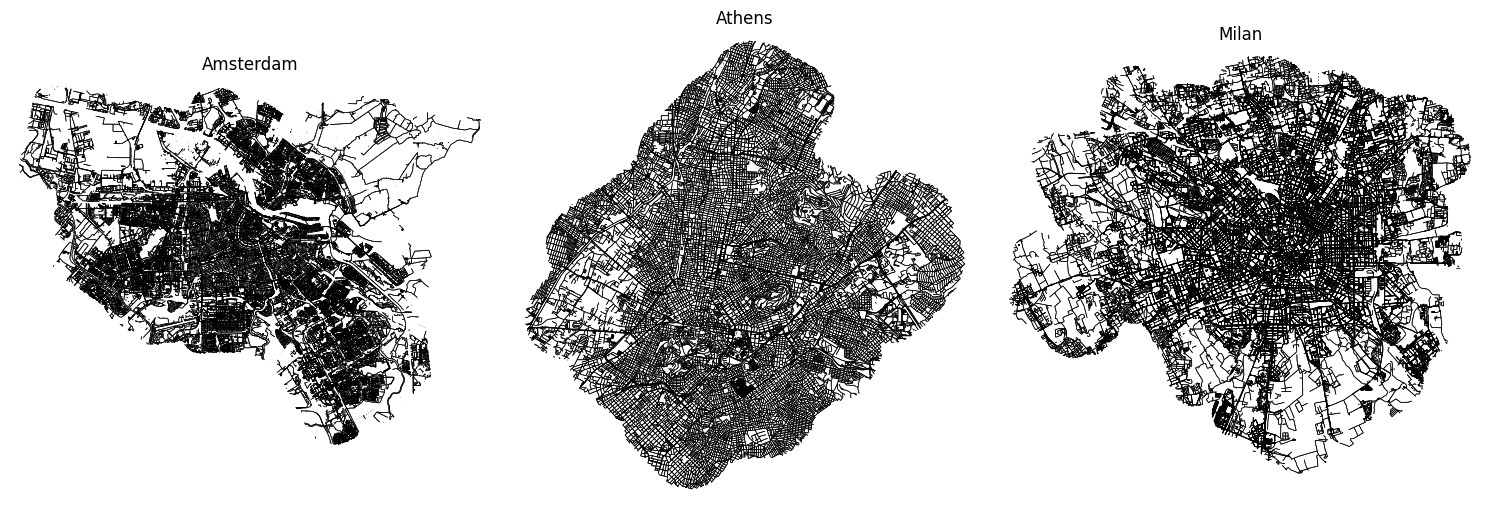

In [ ]:
graphs_with_speeds = {}

# read graphs
for city in cities:
    G_proj = acx.load_graph(
        nodes_path=data_path + f"/street_network/graph_with_cost_{city['name']}_nodes_OSM.geojson",
        edges_path=data_path + f"/street_network/graph_with_cost_{city['name']}_edges_OSM.geojson",
        crs=city["epsg"]
    )
    graphs_with_speeds[city["name"]] = G_proj

# plot graphs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

for ax, city_name, title in zip(axes, city_names, titles):
    ox.plot_graph(
        graphs_with_speeds[city_name],
        ax=ax,
        node_size=0,
        edge_color="black",
        edge_linewidth=0.5,
        show=False,
        close=False
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Estimate Isochrones
For this example we estimate isochrones representing 5, 10, and 15-minutes walk, for 5 locations per city.

In [88]:
gdfs_iso = {}

city_data = [
    {"name": "amsterdam", "hex": ams_hex, "epsg": epsg_ams},
    {"name": "athens", "hex": ath_hex, "epsg": epsg_ath},
    {"name": "milan", "hex": mil_hex, "epsg": epsg_mil},
]

for city in city_data:
    if city["name"] == "athens":
        num1=10
        num2=20
        num3=40
        num4=60
        num5=80

    # elif city["name"] == "milan":
    else:
        num1=100
        num2=200
        num3=300
        num4=400
        num5=500
    # elif city["name"] == "amsterdam":
    #     num1=500
    #     num2=100
    #     num3=1400
    #     num4=300
    #     num5=700
    gdf_iso = acx.calculate_isochrones(
        graphs_with_speeds[city["name"]],
        city["hex"].iloc[[num1, num2, num3, num4, num5]].to_crs(city["epsg"]),
        max_cost=15,
        interval_size=5,
        cost_attr="avg_time",
        city_epsg=city["epsg"],
        max_distance=200,
        method="edges",
        # n_jobs=os.cpu_count() - 1,
        edge_buff=25,
        infill=True,
        base_name=f"walksheds_{city['name']}",
        save_dir="../data/case_studies/walksheds/",
    )

    gdfs_iso[city["name"]] = gdf_iso

/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lambda g: g.wkt if g is not None else None)
/Users/vmlias/repos/accessX/src/accessx/isochrone.py:265: UserWarning: Geometry column does not contain geometry.
  out_csv["geometry"] = out_csv["geometry"].apply(lamb

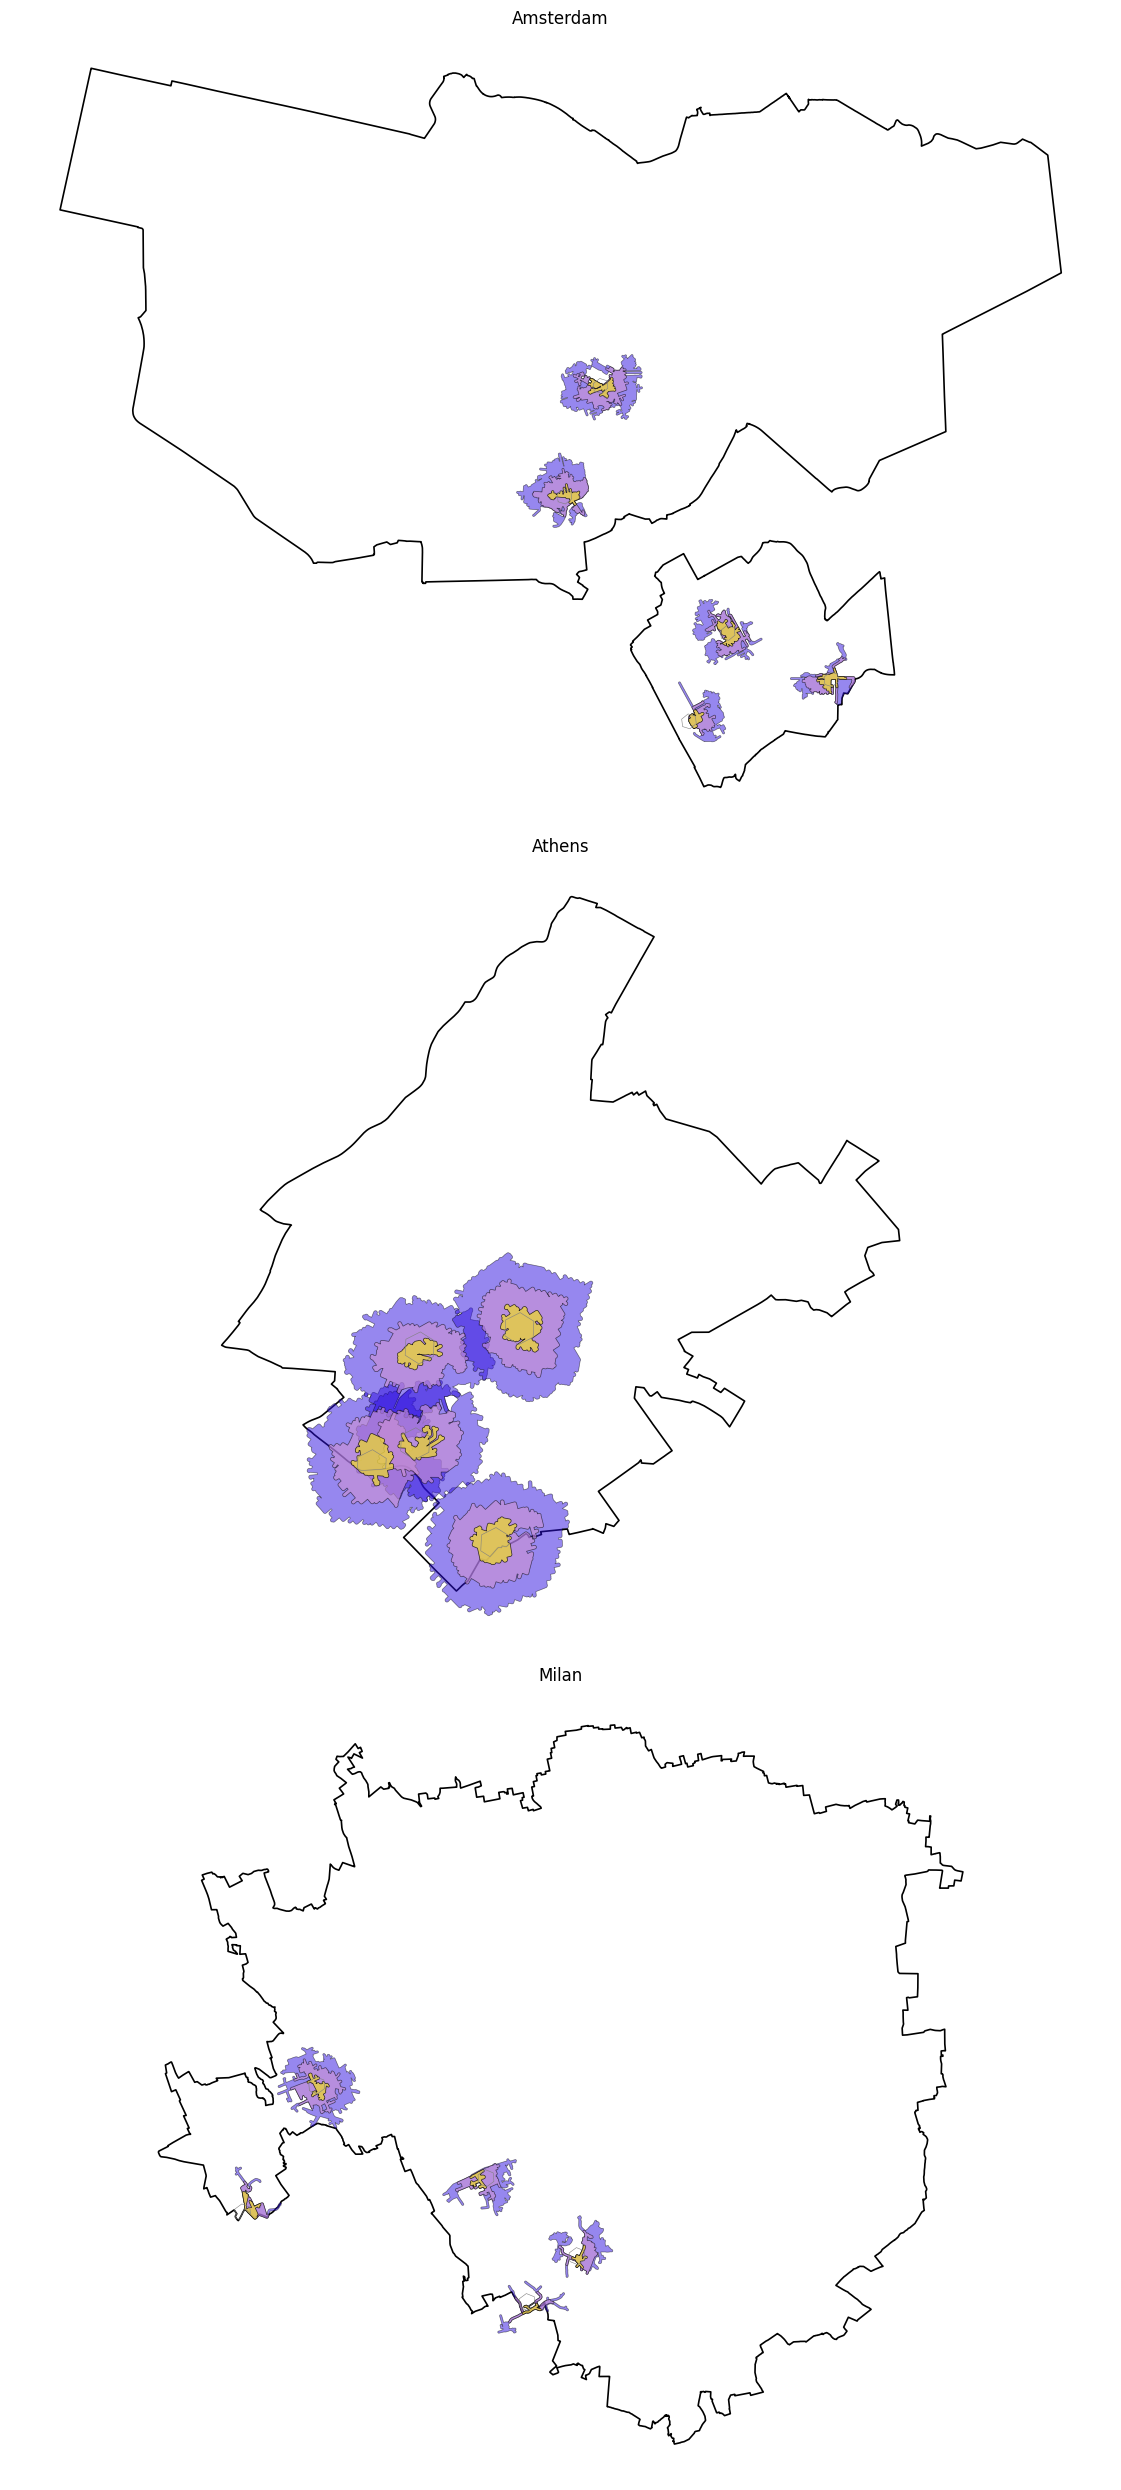

In [89]:
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox

# city boundaries
area_gdfs = {
    "amsterdam": gdf_ams,
    "athens": gdf_ath,
    "milan": gdf_mil,
}

fig, axes = plt.subplots(3, 1, figsize=(15, 25))

titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

for ax, city_name, title in zip(axes, city_names, titles):
    gdf = gdfs_iso[city_name]

    # reproject city boundary to match isochrone CRS
    area = area_gdfs[city_name].to_crs(gdf.crs)

    # plot city boundary first
    area.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)

    # 15 min in the back
    gpd.GeoSeries(gdf["geom_avg_time_15"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#2f10e0", edgecolor="black", linewidth=0.5, alpha=0.5
    )

    # 10 min in the middle
    gpd.GeoSeries(gdf["geom_avg_time_10"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#CE94D3", edgecolor="black", linewidth=0.5, alpha=0.6
    )

    # 5 min on top
    gpd.GeoSeries(gdf["geom_avg_time_5"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#E8D13C", edgecolor="black", linewidth=0.5, alpha=0.8
    )

    # optional: show the sampled hexes too
    gdf.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.4)

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

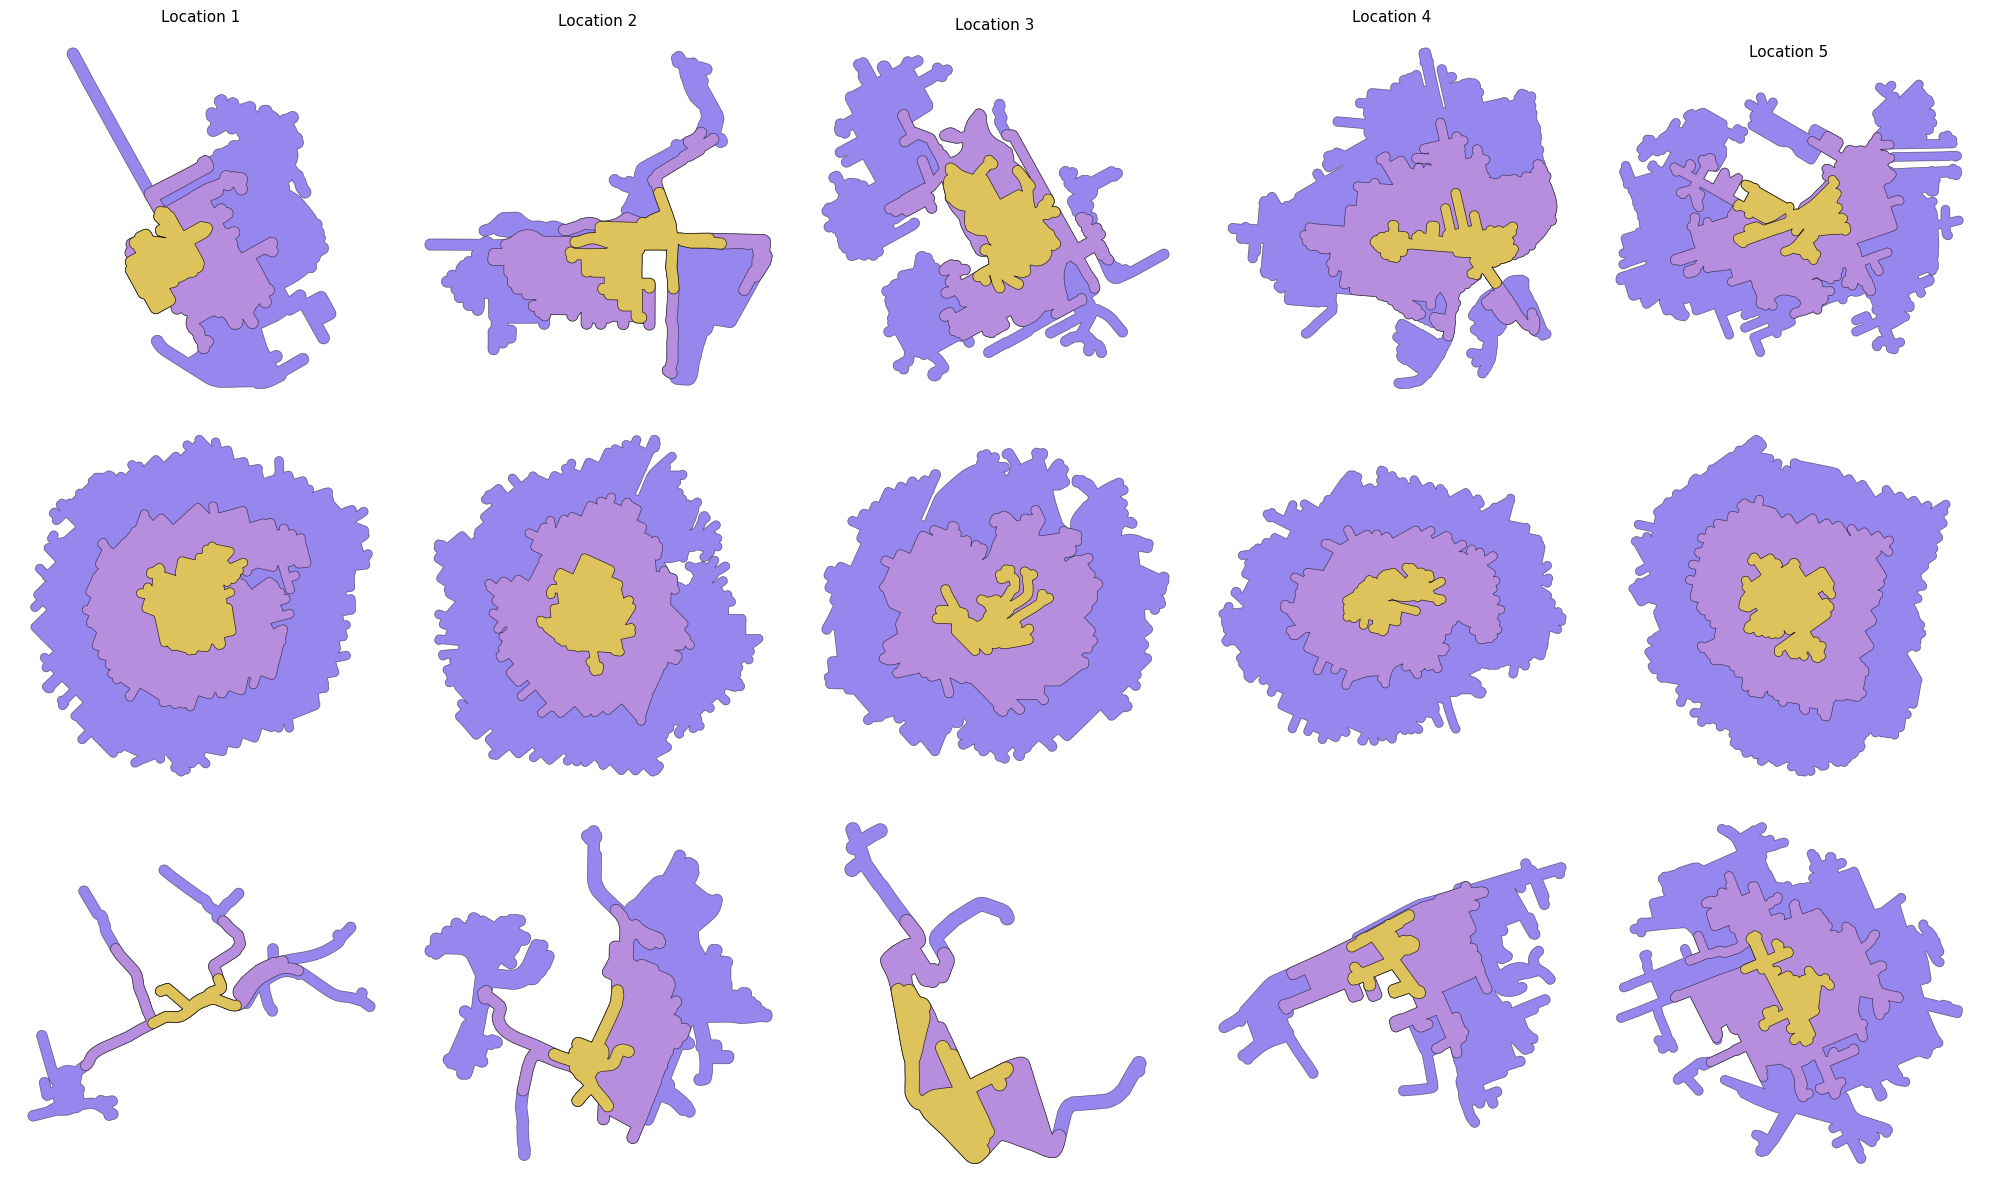

In [94]:
import matplotlib.pyplot as plt
import geopandas as gpd

titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

n_rows = len(city_names)
n_cols = len(gdfs_iso["amsterdam"])  # number of sampled locations

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for i, (city_name, title) in enumerate(zip(city_names, titles)):
    gdf = gdfs_iso[city_name]

    for j in range(n_cols):
        ax = axes[i, j] if n_rows > 1 else axes[j]
        row = gdf.iloc[j]

        # 15 min in the back
        if row["geom_avg_time_15"] is not None:
            gpd.GeoSeries([row["geom_avg_time_15"]], crs=gdf.crs).plot(
                ax=ax, color="#2f10e0", edgecolor="black", linewidth=0.5, alpha=0.5
            )

        # 10 min in the middle
        if row["geom_avg_time_10"] is not None:
            gpd.GeoSeries([row["geom_avg_time_10"]], crs=gdf.crs).plot(
                ax=ax, color="#CE94D3", edgecolor="black", linewidth=0.5, alpha=0.6
            )

        # 5 min on top
        if row["geom_avg_time_5"] is not None:
            gpd.GeoSeries([row["geom_avg_time_5"]], crs=gdf.crs).plot(
                ax=ax, color="#E8D13C", edgecolor="black", linewidth=0.5, alpha=0.8
            )

        # titles
        if i == 0:
            ax.set_title(f"Location {j+1}", fontsize=11)

        if j == 0:
            ax.set_ylabel(title, fontsize=12)

        ax.axis("off")

plt.tight_layout()
plt.show()